In [ ]:
%pip install json
%pip install pathlib
%pip install numpy
%pip install sys
%pip install cv2
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install openpyxl

In [ ]:
import json
from pathlib import Path
import numpy as np
import sys
import openpyxl
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.widgets import Button
import ipywidgets as widgets
from scipy.stats import kruskal
from IPython.display import display, clear_output
from openpyxl import load_workbook
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.formatting.rule import DataBarRule
from openpyxl.utils.dataframe import dataframe_to_rows



project_root = Path("..").resolve()
sys.path.append(str(project_root))
from Calibration.Parameters import CHAMBERS_COLORS


tracking_folder = project_root / "Data"
tracking_files = list(tracking_folder.rglob("*tracking.json"))

print(len(tracking_files), "fichiers trouvés")




lab_letters = ["A","B","C","D","E","F","G","H"]
lab_position = ["top","bottom"]

project_root = Path("..").resolve()
data_folder = project_root / "Data"

experiment_folders = sorted([f.name for f in data_folder.iterdir() if f.is_dir()])

exp_selector = widgets.SelectMultiple(
    options=experiment_folders,
    value=[experiment_folders[0]],
    description='Expériences:',
    style={'description_width':'initial'}
)

letter_selector = widgets.SelectMultiple(
    options=lab_letters,
    value=[lab_letters[0]],
    description='Labyrinthes:',
    style={'description_width':'initial'}
)

position_selector = widgets.SelectMultiple(
    options=lab_position,
    value=[lab_position[0]],
    description='Parties:',
    style={'description_width':'initial'}
)

validate_button = widgets.Button(description='Valider', button_style='success')
output = widgets.Output()

selected_tracking_files = []


def on_validate_clicked(b):
    global selected_tracking_files
    
    with output:
        clear_output()

        selected_experiments = exp_selector.value
        selected_letters = letter_selector.value
        selected_positions = position_selector.value

        print(f"Expérience: {selected_experiments}")
        print(f"Labyrinthes: {selected_letters}")
        print(f"Positions: {selected_positions}")

        selected_tracking_files = []
        for exp in selected_experiments:
            for letter in selected_letters:
                for pos in selected_positions:

                    Mazes_name = f"Maze_{letter}"
                    Maze_name = f"Maze_{letter}_{pos}"

                    tracking_file = data_folder / exp / "Video" / "Mazes" / Mazes_name / f"{Maze_name}_tracking.json"

                    if tracking_file.exists():
                        selected_tracking_files.append(tracking_file)
                    else:
                        print(f"Introuvable: {tracking_file}")

        print(f"\n{len(selected_tracking_files)} fichiers sélectionnés")

        if not selected_tracking_files:
            print("Aucun fichier valide")
            return
        
        
ui = widgets.VBox([
    exp_selector,
    widgets.HBox([letter_selector, position_selector]),
    validate_button,
    output
])
validate_button.on_click(on_validate_clicked)
display(ui)


50 fichiers trouvés


In [ ]:
sample_video = str(tracking_files[0]).replace("_tracking.json", ".mp4")
cap = cv2.VideoCapture(sample_video)
ret, frame = cap.read()
if not ret:
    video_width, video_height = 888, 930
    print(f"Aucune vidéo trouvée, la taille a été initialisée manuellement")
else:
    video_height, video_width = frame.shape[:2]
cap.release()
print(f"Taille vidéo : {video_width} x {video_height}")




mask_path_top = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_top_painted.png"
mask_path_bottom = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_bottom_painted.png"

mask_top = cv2.imread(str(mask_path_top))
mask_bottom = cv2.imread(str(mask_path_bottom))
mask_top = cv2.cvtColor(mask_top, cv2.COLOR_BGR2RGB)
mask_bottom = cv2.cvtColor(mask_bottom, cv2.COLOR_BGR2RGB)


mask_top = cv2.resize(
    mask_top,
    (video_width, video_height),
    interpolation=cv2.INTER_NEAREST
)

mask_bottom = cv2.resize(
    mask_bottom,
    (video_width, video_height),
    interpolation=cv2.INTER_NEAREST
)

excel_file = project_root / "Data_analysis" / "Experimental_design.xlsx"
df = pd.read_excel(excel_file)


maze_cols = [col for col in df.columns if len(col) == 2 and col[0] in "ABCDEFGH"]

maze_df = df.melt(
    id_vars=["Date", "Experience", "Start", "Rejeted"],
    value_vars=maze_cols,
    var_name="Chamber",
    value_name="Condition"
)

maze_df = maze_df.dropna(subset=["Condition"])
maze_df["Condition"] = maze_df["Condition"].str.strip()


def is_rejected(row):
    if pd.isna(row["Rejeted"]):
        return False
    
    rejected_list = str(row["Rejeted"]).replace(" ", "").split("_")
    return row["Chamber"] in rejected_list

maze_df["Rejected_clean"] = maze_df.apply(is_rejected, axis=1)

def is_start(row):
    if pd.isna(row["Start"]):
        return False
    
    start_nums = str(row["Start"]).split("_")
    return row["Chamber"][1] in start_nums

maze_df["Is_start"] = maze_df.apply(is_start, axis=1)
maze_df = maze_df.dropna(subset=["Date", "Experience"])



def extract_info_from_path(file_path):
    file_path = Path(file_path)
    
    exp = file_path.parts[-5]
    
    name = file_path.stem 
    
    parts = name.split("_")
    letter = parts[1]
    position = parts[2]
    
    return exp, letter, position



def extract_info_from_path(file_path):
    file_path = Path(file_path)
    
    exp_folder = file_path.parts[-5]
    
    _, exp_num, date = exp_folder.split("_")
    
    name = file_path.stem
    parts = name.split("_")
    
    letter = parts[1]
    position = parts[2]
    
    return int(exp_num), int(date), letter, position


tracking_info = []

for file in selected_tracking_files:
    exp_num, date, letter, position = extract_info_from_path(file)
    
    maze_numbers = [1,2,3] if position == "top" else [4,5,6]
    
    for num in maze_numbers:
        maze_id = f"{letter}{num}"
        
        tracking_info.append({
            "file": file,
            "Experience": exp_num,
            "Date": date,
            "Chamber": maze_id
        })

tracking_df = pd.DataFrame(tracking_info)


maze_df["Date"] = maze_df["Date"].astype(int)
maze_df["Experience"] = maze_df["Experience"].astype(int)

tracking_df["Date"] = tracking_df["Date"].astype(int)
tracking_df["Experience"] = tracking_df["Experience"].astype(int)


merged_df = tracking_df.merge(
    maze_df,
    on=["Date", "Experience", "Chamber"],
    how="left"
)
merged_df = merged_df[
    ["file", "Experience", "Date", "Chamber", "Condition", "Rejected_clean", "Is_start"]
]

files_to_remove = (
    merged_df
    .groupby("file")["Rejected_clean"]
    .any()
)

files_to_remove = files_to_remove[files_to_remove].index.tolist()

filtered_tracking_files = [
    f for f in selected_tracking_files
    if f not in files_to_remove
]


print(f"Fichiers supprimés lors de l'expérience : {len(files_to_remove)} fichiers")


def build_chamber_map(mask_rgb):
    """
    Convertit un masque RGB en carte d'indices de chambres.

    Parameters
    ----------
    mask_rgb : np.ndarray
        Image RGB du masque (HxWx3)

    Returns
    -------
    chamber_map : np.ndarray
        Carte 2D (HxW) avec ID des chambres
    """

    # Mapping couleurs → ID
    COLOR_TO_ID = {
        (0, 0, 255): 1,   # Chambre_1
        (0, 255, 0): 2,   # Chambre_2
        (255, 0, 0): 3,   # Chambre_3
        (255, 255, 255): 4  # Decision_zone
    }

    height, width, _ = mask_rgb.shape
    chamber_map = np.zeros((height, width), dtype=np.uint8)

    # Remplir la carte
    for color, chamber_id in COLOR_TO_ID.items():
        mask_pixels = np.all(mask_rgb == color, axis=2)
        chamber_map[mask_pixels] = chamber_id

    return chamber_map



class TrajectoryReviewer:
    def __init__(self, selected_tracking_files, mask_top, mask_bottom):
        self.files = selected_tracking_files
        self.mask_top = mask_top
        self.mask_bottom = mask_bottom
        self.chamber_map_top = build_chamber_map(mask_top)
        self.chamber_map_bottom = build_chamber_map(mask_bottom)

        self.idx = 0
        self.saved = []

        self.out = widgets.Output()
        self.label = widgets.HTML()

        self.btn_keep = widgets.Button(description="Garder", button_style='success')
        self.btn_skip = widgets.Button(description="Supprimer", button_style='danger')
        self.btn_back = widgets.Button(description="Retour")
        self.btn_all_keep = widgets.Button(description="Tout garder", button_style='info')

        self.btn_keep.on_click(self.keep)
        self.btn_skip.on_click(self.skip)
        self.btn_back.on_click(self.back)
        self.btn_all_keep.on_click(self.all_keep)

        self.ui = widgets.VBox([
            self.label,
            self.out,
            widgets.HBox([self.btn_keep, self.btn_skip, self.btn_back, self.btn_all_keep])
        ])

        display(self.ui)
        self.show()


    def compute_time_in_chambers(self, df, fps, chamber_map):
        df = df.copy()
        height, width = chamber_map.shape

        df["x_int"] = df["position"].apply(lambda p: p["x"] if p else None)
        df["y_int"] = df["position"].apply(lambda p: p["y"] if p else None)

        df["chamber_id"] = [
            chamber_map[y, x] if x is not None and y is not None and 0 <= x < width and 0 <= y < height else 0
            for x, y in zip(df["x_int"], df["y_int"])
        ]

        inverse_map = {
            0: "Outside",
            1: "Chambre_1",
            2: "Chambre_2",
            3: "Chambre_3",
            4: "Decision_zone"
        }

        df["chamber"] = df["chamber_id"].map(inverse_map)
        return df.groupby("chamber").size() / fps


    def plot_time_distribution(self, time_spent_sec):
        colors = {
            "Outside": "lightgray",
            "Chambre_1": "blue",
            "Chambre_2": "green",
            "Chambre_3": "red",
            "Decision_zone": "white"
        }

        sorted_times = time_spent_sec.sort_values()
        bar_colors = [colors[ch] for ch in sorted_times.index]

        plt.barh(sorted_times.index, sorted_times.values,
                 color=bar_colors, edgecolor='black')

        for i, v in enumerate(sorted_times.values):
            plt.text(v + 0.2, i, f"{v:.1f}s", va='center')

        plt.xlabel("Temps (s)")
        plt.title("Temps par chambre")

    def draw(self, file):
        with open(file) as f:
            data = json.load(f)

        df = pd.DataFrame(data["tracking"])
        fps = data["fps"]

        positions = [p for p in data["tracking"] if p["position"]]
        if not positions:
            return None, None, None, None

        x = [p["position"]["x"] for p in positions]
        y = [p["position"]["y"] for p in positions]

        if "_top" in str(file):
            mask = self.mask_top.copy()
            chamber_map = self.chamber_map_top
        else:
            mask = self.mask_bottom.copy()
            chamber_map = self.chamber_map_bottom

        for i in range(1, len(x)):
            cv2.line(mask, (x[i-1], y[i-1]), (x[i], y[i]), (0,0,0), 2)

        return mask, df, fps, chamber_map

    def show(self):
        while self.idx < len(self.files):
            file = self.files[self.idx]

            cancel_file = file.with_name(file.stem.replace("_tracking", "") + "_tracking_cancelled.txt")
            if cancel_file.exists():
                self.idx += 1
                continue

            img, df, fps, chamber_map = self.draw(file)

            if img is None:
                self.idx += 1
                continue

            time_spent = self.compute_time_in_chambers(df, fps, chamber_map)
            total_time = time_spent.sum()
            time_percentage = (time_spent / total_time) * 100

            with self.out:
                clear_output(wait=True)

                plt.figure(figsize=(10,5))

                plt.subplot(1,2,1)
                plt.imshow(img)
                plt.title("Trajectoire")
                plt.gca().invert_yaxis()
                plt.axis("off")

                plt.subplot(1,2,2)
                self.plot_time_distribution(time_spent)

                plt.tight_layout()
                plt.show()

            self.label.value = f"<h3>{self.idx+1}/{len(self.files)} — {file.resolve()}</h3>"
            return

        self.finish()


    def keep(self, _):
        self.saved.append(self.files[self.idx])
        self.idx += 1
        self.show()

    def all_keep(self, _):
        self.saved.extend(self.files[self.idx:])
        self.idx = len(self.files)
        self.show()

    def skip(self, _):
        self.idx += 1
        self.show()

    def back(self, _):
        if self.idx > 0:
            self.idx -= 1
            if self.files[self.idx] in self.saved:
                self.saved.remove(self.files[self.idx])
        self.show()

    def finish(self):
        clear_output()
        print(f"Terminé : {len(self.saved)} trajectoires gardées")
        
reviewer = TrajectoryReviewer(
    selected_tracking_files,
    mask_top,
    mask_bottom
)


### Veuillez entrer le nom du dossier dans lequel tous les résultats de l'analyse seront enregistrés.

In [26]:
# Nom du dossier de sortie
folder_name = "Results_all_files_test"

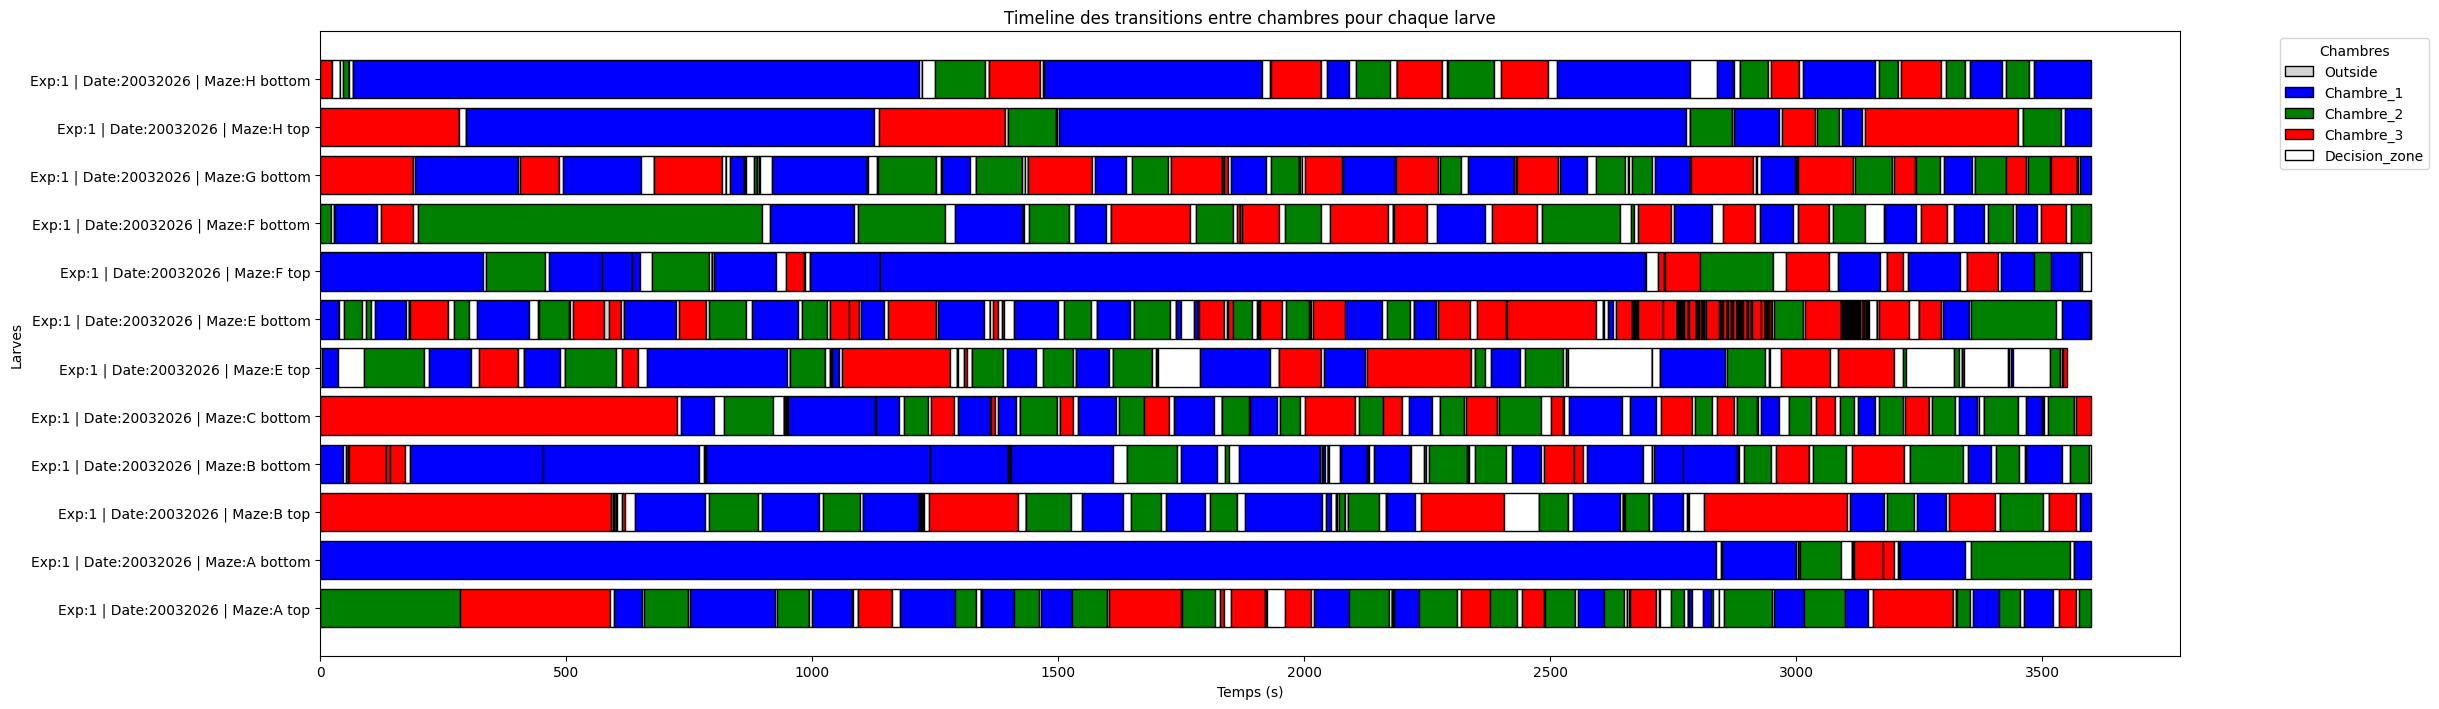

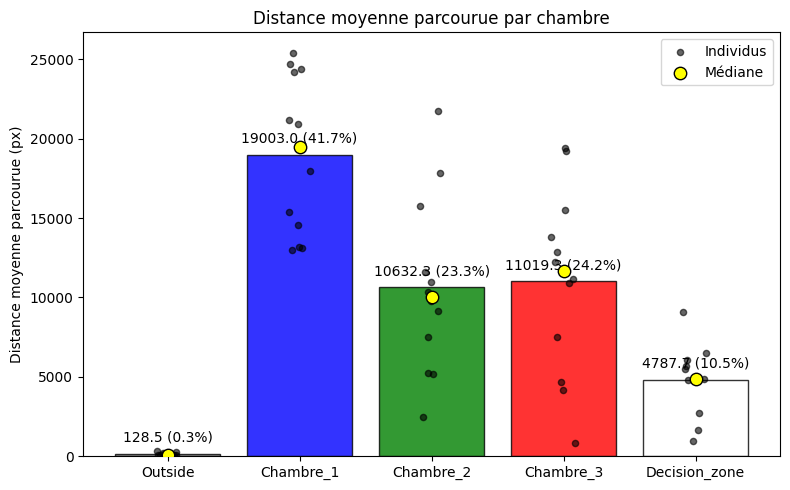

C:\Users\julie\AppData\Local\Temp\ipykernel_24892\2793492218.py:253: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


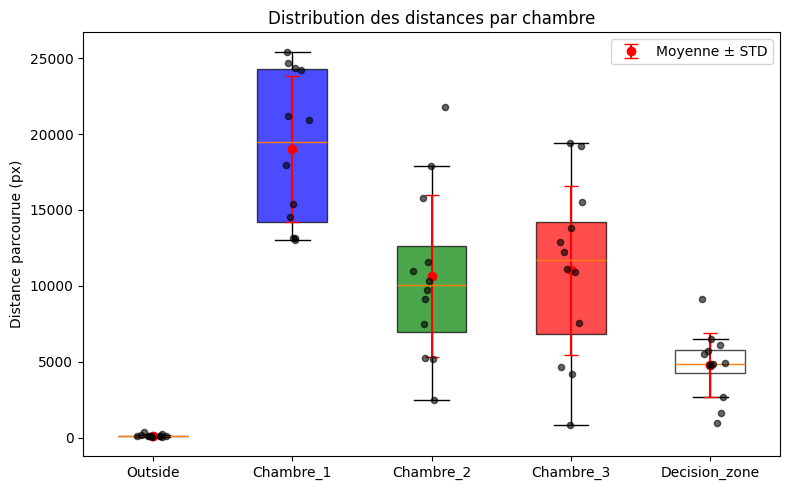

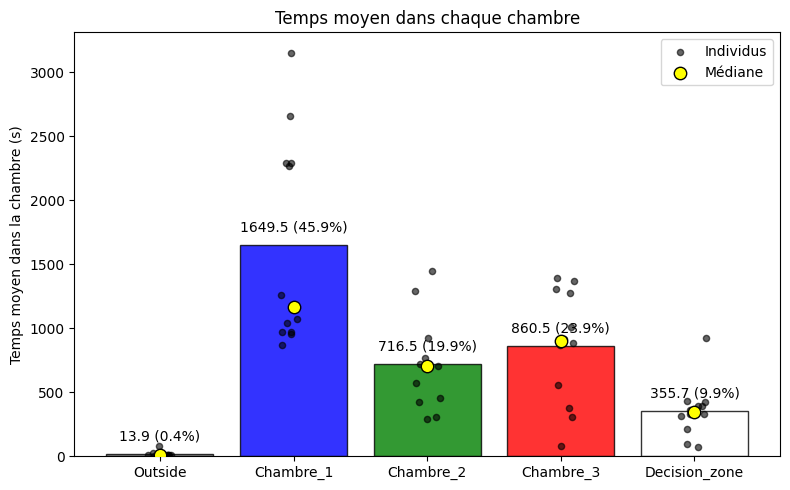

C:\Users\julie\AppData\Local\Temp\ipykernel_24892\2793492218.py:348: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


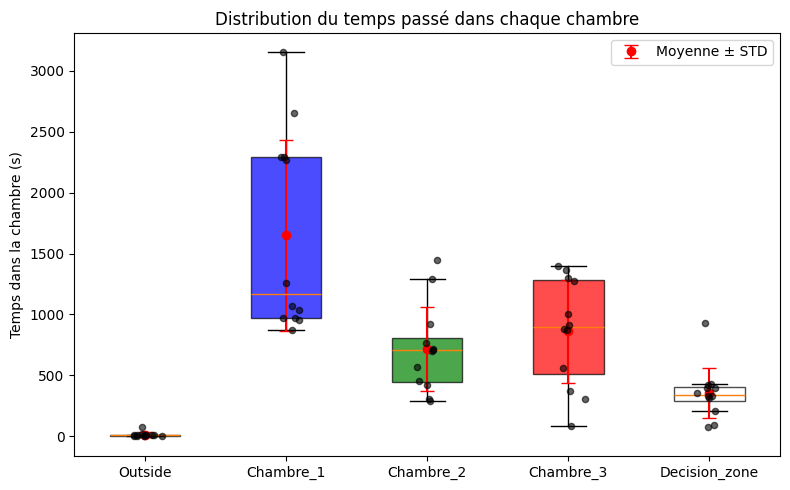

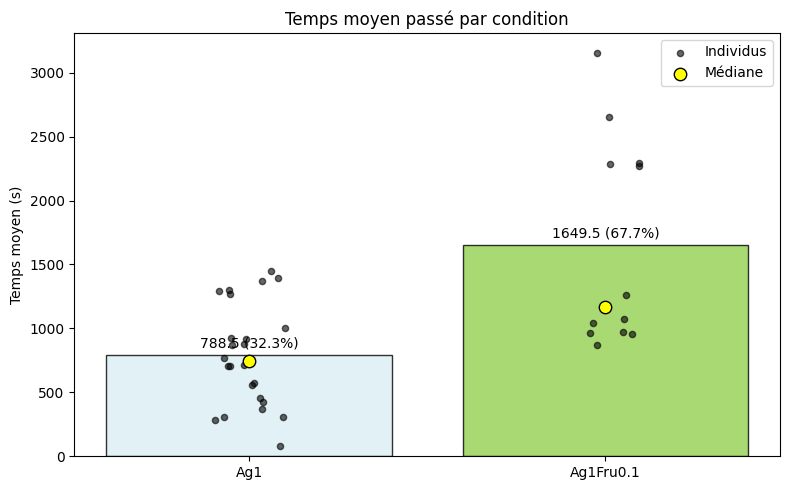

C:\Users\julie\AppData\Local\Temp\ipykernel_24892\2793492218.py:585: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


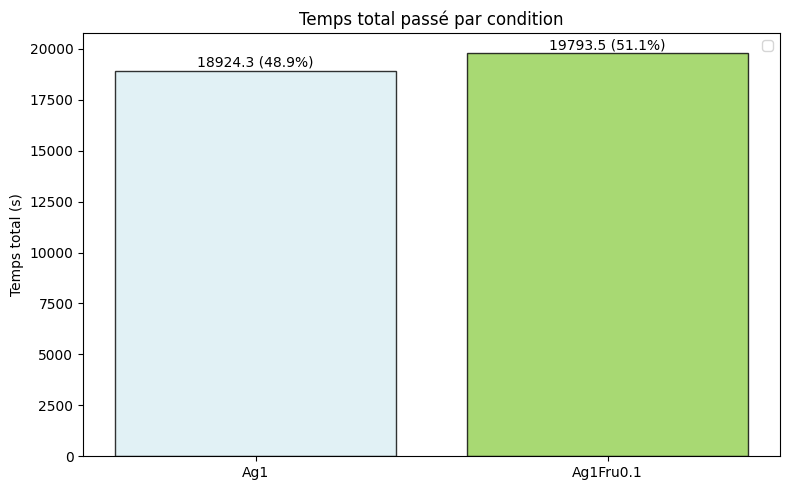

C:\Users\julie\AppData\Local\Temp\ipykernel_24892\2793492218.py:602: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


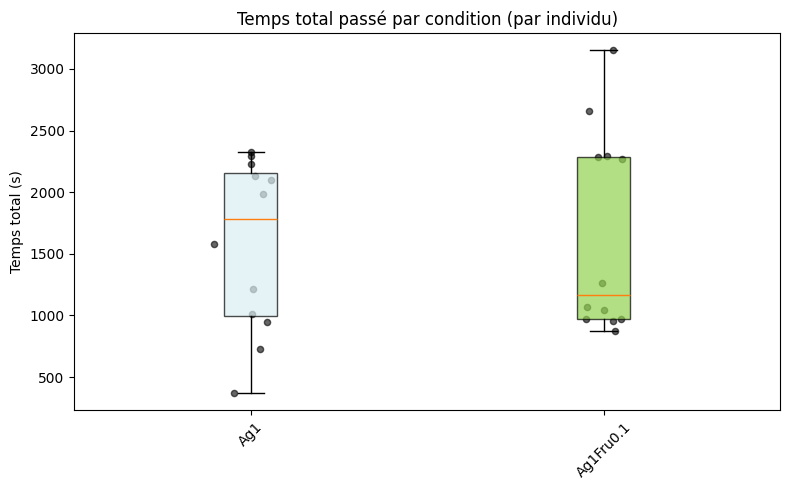

Préférence fructose vs agar (4e chambre exclue)
Moyenne prop_fru = 0.503
t = 2.610, p = 0.0242696


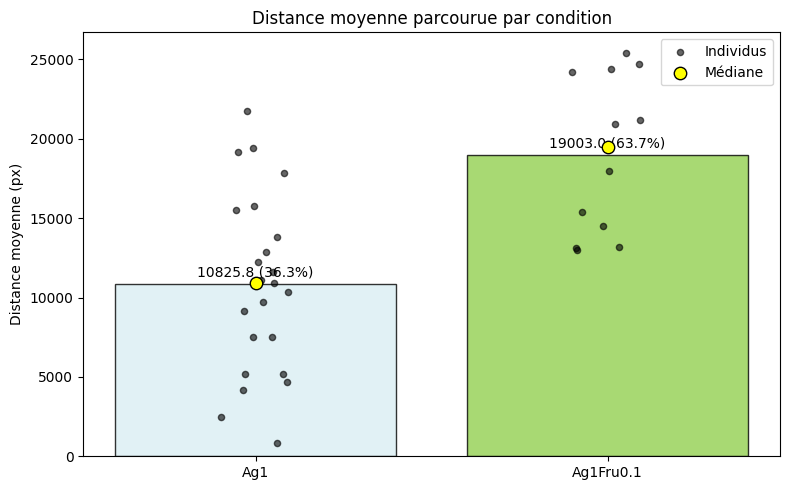

C:\Users\julie\AppData\Local\Temp\ipykernel_24892\2793492218.py:749: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


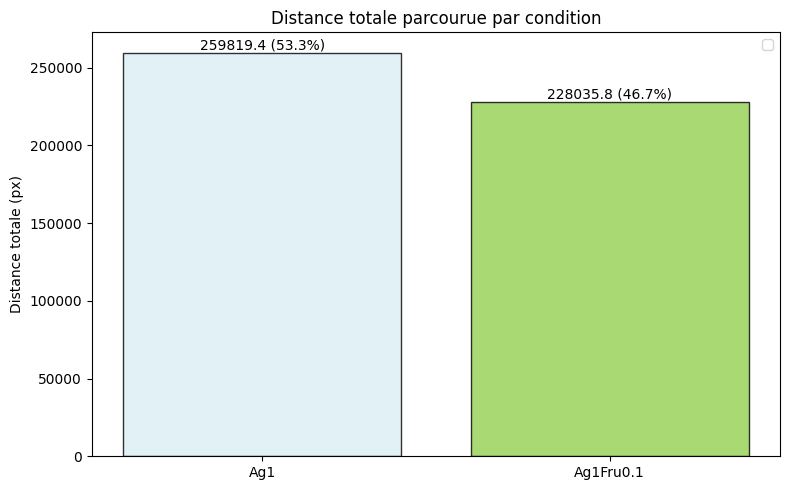

C:\Users\julie\AppData\Local\Temp\ipykernel_24892\2793492218.py:765: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


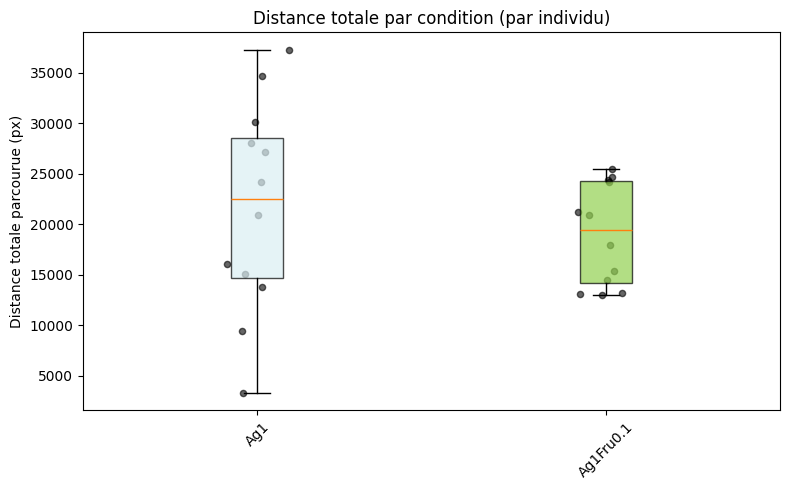

Préférence fructose vs agar (4e chambre exclue)
Moyenne prop_fru = 0.491
t = 2.865, p = 0.0153883


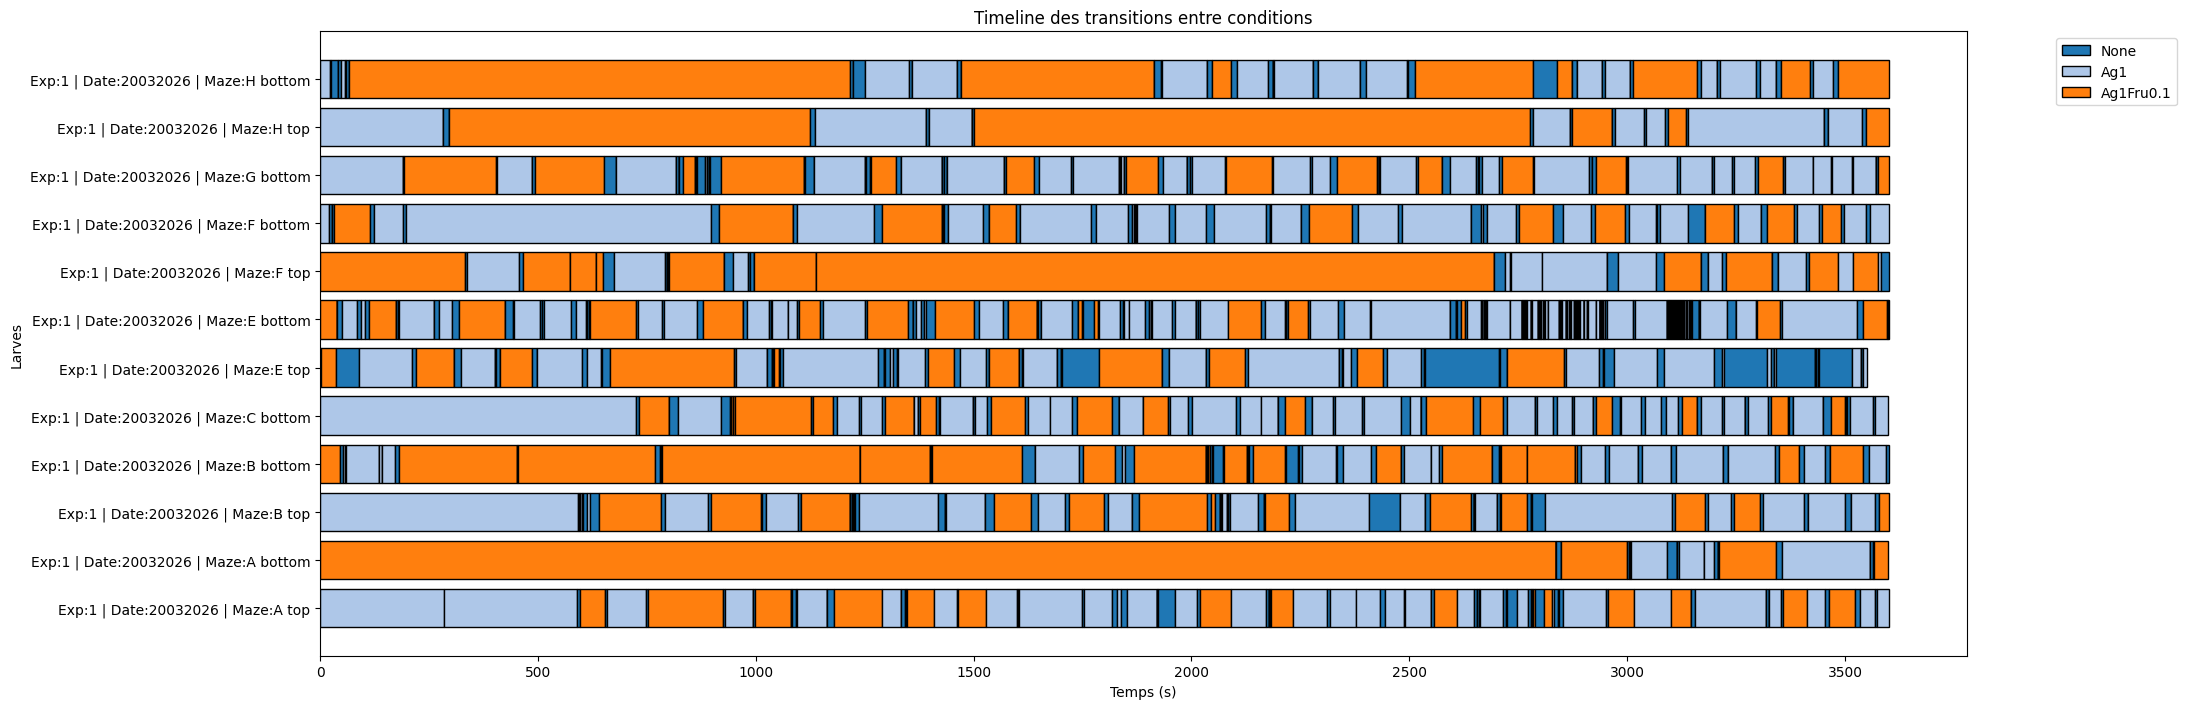

C:\Users\julie\AppData\Local\Temp\ipykernel_24892\2793492218.py:984: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_time = all_files_df.groupby('Chamber_name').apply(
C:\Users\julie\AppData\Local\Temp\ipykernel_24892\2793492218.py:987: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_dist = all_files_df.groupby('Chamber_name').apply(
C:\Users\julie\AppData\Local\Temp\ipykernel_24892\2793492218.py:1006: Fu

Fichier Excel complet créé : C:\Users\julie\Downloads\Projet CEA\Rewrite\Data_analysis\Results_all_files_test\Results_all_files_test.xlsx


In [27]:
output_dir = project_root / 'Data_analysis' /folder_name
output_dir.mkdir(exist_ok=True)
def save_fig(name):
    path = output_dir / name
    plt.savefig(path, dpi=300, bbox_inches="tight")


kept_files = reviewer.saved
df_kept = merged_df[merged_df["file"].isin(kept_files)]

all_times = {}
all_distances = {}

id_to_chamber = {
    0: "Outside",
    1: "Chambre_1",
    2: "Chambre_2",
    3: "Chambre_3",
    4: "Decision_zone"
}

def complete_dict(d):
    keys = ["Outside", "Chambre_1", "Chambre_2", "Chambre_3", "Decision_zone"]
    return {k: d.get(k, 0) for k in keys}


for file in kept_files:
    file_name = file

    with open(file) as f:
        data = json.load(f)

    df = pd.DataFrame(data["tracking"])
    fps = data["fps"]

    chamber_map = build_chamber_map(mask_top) if "_top" in str(file) else build_chamber_map(mask_bottom)

    #  TIMES
    times = reviewer.compute_time_in_chambers(df, fps, chamber_map)
    all_times[file_name] = complete_dict(times.to_dict())

    #  DISTANCES
    height, width = chamber_map.shape

    df["x_int"] = df["position"].apply(lambda p: p["x"] if p else None)
    df["y_int"] = df["position"].apply(lambda p: p["y"] if p else None)

    df["chamber_id"] = [
        chamber_map[y, x] if x is not None and y is not None and 0 <= x < width and 0 <= y < height else 0
        for x, y in zip(df["x_int"], df["y_int"])
    ]

    distances = df.groupby("chamber_id")["distance_px"].sum()

    all_distances[file_name] = complete_dict({
        id_to_chamber[ch]: dist for ch, dist in distances.items()
    })
    

    
df_times = pd.DataFrame.from_dict(all_times, orient="index")
mean_times = df_times.mean()
std_times = df_times.std()
df_dist = pd.DataFrame.from_dict(all_distances, orient="index")
mean_distances = df_dist.mean()
std_distances = df_dist.std()

transition_data = []

for file in kept_files:
    file_name = file

    with open(file) as f:
        data = json.load(f)

    df = pd.DataFrame(data["tracking"])
    fps = data["fps"]

    chamber_map = build_chamber_map(mask_top) if "_top" in str(file) else build_chamber_map(mask_bottom)
    height, width = chamber_map.shape

    # --- Extraction positions ---
    df["x"] = df["position"].apply(lambda p: p["x"] if p else None)
    df["y"] = df["position"].apply(lambda p: p["y"] if p else None)

    # --- Attribution chambre (IMPORTANT : None -> Outside = 0) ---
    df["chamber_id"] = [
        chamber_map[y, x] if x is not None and y is not None and 0 <= x < width and 0 <= y < height else 0
        for x, y in zip(df["x"], df["y"])
    ]
    

    # --- Calcul des transitions ---
    last_chamber = 0
    time_in_chamber = 0
    #last_chamber = df["chamber_id"].iloc[0]
    #time_in_chamber = 1 / fps

    for chamber in df["chamber_id"].iloc[1:]:
        if chamber == last_chamber:
            time_in_chamber += 1 / fps
        else:
            transition_data.append({
                "file": file_name,
                "from": last_chamber,
                "to": chamber,
                "time_in_from": time_in_chamber
            })
            last_chamber = chamber
            time_in_chamber = 1 / fps

    #Ajouter le dernier segment
    transition_data.append({
        "file": file_name,
        "from": last_chamber,
        "to": last_chamber,
        "time_in_from": time_in_chamber
    })
    
    
    df_transitions = pd.DataFrame(transition_data)

id_to_chamber = {
    0: "Outside",
    1: "Chambre_1",
    2: "Chambre_2",
    3: "Chambre_3",
    4: "Decision_zone"
}

# Mapping + gestion des valeurs inconnues
df_transitions["from_str"] = df_transitions["from"].map(id_to_chamber).fillna("Unknown")
df_transitions["to_str"] = df_transitions["to"].map(id_to_chamber).fillna("Unknown")
df_kept_unique = df_kept.groupby('file').agg({
    'Chamber': 'first',   # ou 'max', 'min', etc.
    'Experience': 'first',
    'Date': 'first'
}).reset_index()
df_transitions = df_transitions.merge(
    df_kept_unique,
    on='file',
    how='left'
)


df_transitions["larva_id"] = df_transitions["file"].apply(lambda f: Path(f).stem)

larvae = df_transitions["file"].unique()
chamber_colors_plot = {
    "Outside": "lightgray",
    "Chambre_1": "blue",
    "Chambre_2": "green",
    "Chambre_3": "red",
    "Decision_zone": "white"
}

larva_labels = []
for larva in larvae:
    larva_transitions = df_transitions[df_transitions["file"] == larva]
    exp = larva_transitions["Experience"].iloc[0]
    date = larva_transitions["Date"].iloc[0]
    number_chamber = int(larva_transitions["Chamber"].iloc[0][1])
    letter = larva_transitions["Chamber"].iloc[0][0]
    if number_chamber>3:
        maze = 'bottom'
    else:
        maze = 'top'
    larva_labels.append(f"Exp:{exp} | Date:{date} | Maze:{letter} {maze}")

plt.figure(figsize=(22, len(larvae)*0.6))

for i, larva in enumerate(larvae):
    larva_transitions = df_transitions[df_transitions["file"] == larva]
    t_start = 0
    for _, row in larva_transitions.iterrows():
        t_end = t_start + row["time_in_from"]
        plt.barh(
            i, 
            t_end - t_start, 
            left=t_start, 
            color=chamber_colors_plot.get(row["from_str"], "gray"), 
            edgecolor="black"
        )
        t_start = t_end

plt.yticks(range(len(larvae)), larva_labels)
plt.xlabel("Temps (s)")
plt.ylabel("Larves")
plt.title("Timeline des transitions entre chambres pour chaque larve")
plt.tight_layout()

legend_elements = [Patch(facecolor=color, edgecolor='black', label=ch) 
                   for ch, color in chamber_colors_plot.items()]
plt.legend(handles=legend_elements, title="Chambres", bbox_to_anchor=(1.05, 1), loc='upper left')
save_fig("Transitions_by_chamber.png")
plt.show()


df_kept = merged_df[merged_df["file"].isin(kept_files)]
chambers = mean_distances.index.tolist()
means = mean_distances.values
bar_colors = [CHAMBERS_COLORS.get(ch, "gray") for ch in chambers]
stds = std_distances.values

total_mean = means.sum()

plt.figure(figsize=(8,5))
bars = plt.bar(
    chambers, means,
    color=bar_colors, edgecolor='black',
    alpha=0.8, capsize=5
)

for bar, mean in zip(bars, means):
    percent = mean / total_mean * 100  # <- calcul du pourcentage
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(stds)*0.1,
        f"{mean:.1f} ({percent:.1f}%)",  # <- affiche valeur + %
        ha='center',
        va='bottom'
    )

df_dist = pd.DataFrame.from_dict(all_distances, orient="index")

points_added = False
median_added = False
for i, ch in enumerate(chambers):
    values = df_dist[ch].dropna().values
    x = np.full(len(values), i) + np.random.uniform(-0.1, 0.1, len(values))
    plt.scatter(x, values, color='black', alpha=0.6, s=20, zorder=3, label="Individus" if not points_added else "")
    points_added = True

    median = np.median(values)
    plt.scatter(i, median, color='yellow', edgecolor='black', s=80, zorder=4, label="Médiane" if not median_added else "")
    median_added = True
    

plt.ylabel("Distance moyenne parcourue (px)")
plt.title("Distance moyenne parcourue par chambre")

plt.legend()
plt.tight_layout()
save_fig("Mean_distance_by_chamber.png")
plt.show()



plt.figure(figsize=(8,5))

data = [df_dist[ch].dropna().values for ch in chambers]

box = plt.boxplot(
    data,
    patch_artist=True,
    labels=chambers,
    showfliers=False  # optionnel (enlève les outliers)
)

for patch, ch in zip(box['boxes'], chambers):
    patch.set_facecolor(CHAMBERS_COLORS.get(ch, "gray"))
    patch.set_alpha(0.7)

for i, ch in enumerate(chambers):
    values = df_dist[ch].dropna().values
    x = np.random.normal(i+1, 0.05, size=len(values))
    plt.scatter(x, values, color='black', alpha=0.6, s=20, zorder=3)

for i, ch in enumerate(chambers):
    values = df_dist[ch].dropna().values
    mean = np.mean(values)
    std = np.std(values)

    plt.errorbar(
        i+1, mean,
        yerr=std,
        fmt='o',
        color='red',
        capsize=5,
        label="Moyenne ± STD" if i == 0 else ""
    )

plt.ylabel("Distance parcourue (px)")
plt.title("Distribution des distances par chambre")

plt.legend()
plt.tight_layout()
save_fig("Distance_by_chamber.png")
plt.show()



chambers = mean_times.index.tolist()
means = mean_times.values
bar_colors = [CHAMBERS_COLORS.get(ch, "gray") for ch in chambers]
stds = std_times.values

total_mean = means.sum()

plt.figure(figsize=(8,5))
bars = plt.bar(
    chambers, means,
    color=bar_colors, edgecolor='black',
    alpha=0.8, capsize=5
)

for bar, mean in zip(bars, means):
    percent = mean / total_mean * 100  # <- calcul du pourcentage
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(stds)*0.1,
        f"{mean:.1f} ({percent:.1f}%)",  # <- affiche valeur + %
        ha='center',
        va='bottom'
    )

df_dist = pd.DataFrame.from_dict(all_times, orient="index")

points_added = False
median_added = False
for i, ch in enumerate(chambers):
    values = df_dist[ch].dropna().values
    x = np.full(len(values), i) + np.random.uniform(-0.1, 0.1, len(values))
    plt.scatter(x, values, color='black', alpha=0.6, s=20, zorder=3, label="Individus" if not points_added else "")
    points_added = True

    median = np.median(values)
    plt.scatter(i, median, color='yellow', edgecolor='black', s=80, zorder=4, label="Médiane" if not median_added else "")
    median_added = True
    

plt.ylabel("Temps moyen dans la chambre (s)")
plt.title("Temps moyen dans chaque chambre")

plt.legend()
plt.tight_layout()
save_fig("Mean_time_by_chamber.png")
plt.show()



plt.figure(figsize=(8,5))

# Données
df_times = pd.DataFrame.from_dict(all_times, orient="index")
data = [df_times[ch].dropna().values for ch in chambers]

box = plt.boxplot(
    data,
    patch_artist=True,
    labels=chambers,
    showfliers=False
)

for patch, ch in zip(box['boxes'], chambers):
    patch.set_facecolor(CHAMBERS_COLORS.get(ch, "gray"))
    patch.set_alpha(0.7)

for i, ch in enumerate(chambers):
    values = df_times[ch].dropna().values
    x = np.random.normal(i+1, 0.05, size=len(values))
    plt.scatter(x, values, color='black', alpha=0.6, s=20, zorder=3)

for i, ch in enumerate(chambers):
    values = df_times[ch].dropna().values
    mean = np.mean(values)
    std = np.std(values)

    plt.errorbar(
        i+1, mean,
        yerr=std,
        fmt='o',
        color='red',
        capsize=5,
        label="Moyenne ± STD" if i == 0 else ""
    )

plt.ylabel("Temps dans la chambre (s)")
plt.title("Distribution du temps passé dans chaque chambre")

plt.legend()
plt.tight_layout()
save_fig("Time_by_chamber.png")
plt.show()



df_transitions_condition = df_transitions.merge(on="file", right=df_kept[["file", "Condition"]], how="left")


def map_chamber_name(chamber):
    if len(chamber) >= 2 and chamber[0] in lab_letters:

        chamber_id = int(chamber[1])
        if chamber_id > 3:
            chamber_id = ((chamber_id - 1) % 3) + 1
        return f"Chambre_{chamber_id}"

    elif chamber == "Decision_zone":
        return "Decision_zone"
    elif chamber == "Outside":
        return "Outside"
    else:
        return "Unknown"
    
    
all_files_df = []
for file in kept_files:
    merged_df_file = merged_df[merged_df["file"] == file].copy()
    merged_df_file = merged_df_file[["file", "Experience", "Date", "Chamber", "Condition", "Rejected_clean", "Is_start"]]

    # Mapping des chambres A1-A6
    merged_df_file["Chamber_name"] = merged_df_file["Chamber"].apply(map_chamber_name)

    # Ajouter les temps correspondants depuis all_times
    merged_df_file["Time_in_chamber"] = merged_df_file["Chamber_name"].apply(
        lambda ch: all_times[file].get(ch, 0)
    )
    
    merged_df_file["Distance_in_chamber"] = merged_df_file["Chamber_name"].apply(
        lambda ch: all_distances[file].get(ch, 0)
    )

    # Ajouter Outside et Decision_zone sans condition
    for special_ch in ["Outside", "Decision_zone"]:
        merged_df_file = pd.concat([
            merged_df_file,
            pd.DataFrame({
                "file": [file],
                "Experience": [merged_df_file["Experience"].iloc[0]],
                "Date": [merged_df_file["Date"].iloc[0]],
                "Chamber": [special_ch],
                "Condition": [None],  # pas de condition
                "Rejected_clean": [False],
                "Is_start": [False],
                "Chamber_name": [special_ch],
                "Time_in_chamber": [all_times[file].get(special_ch, 0)],
                "Distance_in_chamber": [all_distances[file].get(special_ch, 0)]
            })
        ], ignore_index=True)
    all_files_df.append(merged_df_file)




wb = load_workbook(excel_file, data_only=True)
ws = wb.active

condition_colors = {}

for col in range(15, ws.max_column + 1):
    for row in range(2, ws.max_row + 1):  # lignes de données
        cell = ws.cell(row=row, column=col)
        val = cell.value
        if val is not None:
            fill = cell.fill
            if fill.start_color and fill.start_color.rgb:
                rgb = fill.start_color.rgb  # format 'FFRRGGBB'
                hex_color = "#" + rgb[-6:]  # enlever l'alpha FF si présent
                # garder la couleur unique pour chaque condition
                if val not in condition_colors:
                    condition_colors[val] = hex_color


df_all = pd.concat(all_files_df, ignore_index=True)
df_conditions = df_all.dropna(subset=['Condition'])

mean_times = df_conditions.groupby('Condition')['Time_in_chamber'].mean()
std_times = df_conditions.groupby('Condition')['Time_in_chamber'].std()

conditions = mean_times.index.tolist()
x = np.arange(len(conditions))

total_mean = mean_times.sum()  # <- total pourcentage

plt.figure(figsize=(8,5))

bars = plt.bar(
    x,
    mean_times.values,
    color=[condition_colors.get(c, "gray") for c in conditions],
    edgecolor='black',
    alpha=0.8,
    capsize=5
)

for i, mean_val in enumerate(mean_times.values):
    percent = mean_val / total_mean * 100  # <- calcul du pourcentage
    plt.text(
        x[i],
        mean_val + max(std_times.values)*0.05,
        f"{mean_val:.1f} ({percent:.1f}%)",  # <- affiche valeur + %
        ha='center',
        va='bottom',
        fontsize=10
    )

points_added = False
median_added = False

for i, cond in enumerate(conditions):
    values = df_conditions[df_conditions['Condition'] == cond]['Time_in_chamber'].values
    
    jitter = np.random.uniform(-0.1, 0.1, size=len(values))
    plt.scatter(x[i] + jitter, values, color='black', alpha=0.6, s=20, zorder=3,
                label="Individus" if not points_added else "")
    points_added = True

    median_val = np.median(values)
    plt.scatter(x[i], median_val, color='yellow', edgecolor='black', s=80, zorder=4,
                label="Médiane" if not median_added else "")
    median_added = True

plt.xticks(x, conditions)
plt.ylabel("Temps moyen (s)")
plt.title("Temps moyen passé par condition")
plt.legend()
plt.tight_layout()
save_fig("Mean_time_by_condition.png")
plt.show()


df_transitions = pd.DataFrame(transition_data)

id_to_chamber = {
    0: "Outside",
    1: "Chambre_1",
    2: "Chambre_2",
    3: "Chambre_3",
    4: "Decision_zone"
}

# Mapping + gestion des valeurs inconnues
df_transitions["from_str"] = df_transitions["from"].map(id_to_chamber).fillna("Unknown")
df_transitions["to_str"] = df_transitions["to"].map(id_to_chamber).fillna("Unknown")
df_kept_unique = df_kept.groupby('file').agg({
    'Chamber': 'first',   # ou 'max', 'min', etc.
    'Experience': 'first',
    'Date': 'first'
}).reset_index()
df_transitions = df_transitions.merge(
    df_kept_unique,
    on='file',
    how='left'
)



df_all = pd.concat(all_files_df, ignore_index=True)
df_conditions = df_all.dropna(subset=['Condition'])

sum_times = df_conditions.groupby('Condition')['Time_in_chamber'].sum()
std_times = df_conditions.groupby('Condition')['Time_in_chamber'].std()

conditions = sum_times.index.tolist()
x = np.arange(len(conditions))

total_time = sum(sum_times.values)

plt.figure(figsize=(8,5))

bars = plt.bar(
    x,
    sum_times.values,
    color=[condition_colors.get(c, "gray") for c in conditions],
    edgecolor='black',
    alpha=0.8,
    capsize=5
)

for i, sum_val in enumerate(sum_times.values):
    percent = sum_val / total_time * 100
    plt.text(
        x[i],
        sum_val + max(std_times.values)*0.05,
        f"{sum_val:.1f} ({percent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(x, conditions)
plt.ylabel("Temps total (s)")
plt.title("Temps total passé par condition")
plt.legend()
plt.tight_layout()
save_fig("Total_time_by_condition.png")
plt.show()



df_time_sum = df_conditions.groupby(['file', 'Condition'])['Time_in_chamber'].sum().reset_index()
conditions = df_time_sum['Condition'].unique()

plt.figure(figsize=(8,5))

data = [
    df_time_sum[df_time_sum['Condition'] == cond]['Time_in_chamber'].values
    for cond in conditions
]

box = plt.boxplot(
    data,
    labels=conditions,
    patch_artist=True,
    showfliers=False
)

# couleurs
for patch, cond in zip(box['boxes'], conditions):
    patch.set_facecolor(condition_colors.get(cond, "gray"))
    patch.set_alpha(0.7)

# points individuels (chaque larve)
for i, cond in enumerate(conditions):
    values = df_time_sum[df_time_sum['Condition'] == cond]['Time_in_chamber'].values

    x = np.random.normal(i+1, 0.05, size=len(values))
    plt.scatter(x, values, color='black', alpha=0.6, s=20)

plt.ylabel("Temps total (s)")
plt.title("Temps total passé par condition (par individu)")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("Total_time_by_condition.png")
plt.show()



import pandas as pd
from scipy.stats import ttest_1samp

# --- 1. Garder uniquement agar et fructose ---
df_sub = df_time_sum[df_time_sum['Condition'].isin(['Ag1', 'Ag1Fru0.1'])]

# --- 2. Temps fructose par larve ---
df_fru = df_sub[df_sub['Condition'] == 'Ag1Fru0.1']
df_fru = df_fru.groupby('file')['Time_in_chamber'].sum().reset_index()
df_fru = df_fru.rename(columns={'Time_in_chamber': 'Time_in_chamber_fru'})

# --- 3. Temps agar par larve (2 chambres combinées) ---
df_agar = df_sub[df_sub['Condition'] == 'Ag1']
df_agar = df_agar.groupby('file')['Time_in_chamber'].sum().reset_index()
df_agar = df_agar.rename(columns={'Time_in_chamber': 'Time_in_chamber_agar'})

# --- 4. Fusion ---
df_prop = pd.merge(df_fru, df_agar, on='file')

# --- 5. Proportion fructose (relative à agar + fructose) ---
df_prop['prop_fru'] = df_prop['Time_in_chamber_fru'] / (df_prop['Time_in_chamber_fru'] + df_prop['Time_in_chamber_agar'])

# --- 6. Test statistique ---
# hypothèse nulle : 1 chambre fructose vs 2 agar → 1/3
stat, p = ttest_1samp(df_prop['prop_fru'], popmean=1/3)

# --- 7. Résultats ---
print("Préférence fructose vs agar (4e chambre exclue)")
print(f"Moyenne prop_fru = {df_prop['prop_fru'].mean():.3f}")
print(f"t = {stat:.3f}, p = {p:.7f}")


mean_distances = df_conditions.groupby('Condition')['Distance_in_chamber'].mean()
std_distances = df_conditions.groupby('Condition')['Distance_in_chamber'].std()

conditions = mean_distances.index.tolist()
x = np.arange(len(conditions))

total_mean = mean_distances.sum()  # <- total pourcentage

plt.figure(figsize=(8,5))

bars = plt.bar(
    x,
    mean_distances.values,
    color=[condition_colors.get(c, "gray") for c in conditions],
    edgecolor='black',
    alpha=0.8,
    capsize=5
)

for i, mean_val in enumerate(mean_distances.values):
    percent = mean_val / total_mean * 100  # <- calcul du pourcentage
    plt.text(
        x[i],
        mean_val + max(std_distances.values)*0.05,
        f"{mean_val:.1f} ({percent:.1f}%)",  # <- affiche valeur + %
        ha='center',
        va='bottom',
        fontsize=10
    )

points_added = False
median_added = False

for i, cond in enumerate(conditions):
    values = df_conditions[df_conditions['Condition'] == cond]['Distance_in_chamber'].values
    
    jitter = np.random.uniform(-0.1, 0.1, size=len(values))
    plt.scatter(x[i] + jitter, values, color='black', alpha=0.6, s=20, zorder=3,
                label="Individus" if not points_added else "")
    points_added = True

    median_val = np.median(values)
    plt.scatter(x[i], median_val, color='yellow', edgecolor='black', s=80, zorder=4,
                label="Médiane" if not median_added else "")
    median_added = True

plt.xticks(x, conditions)
plt.ylabel("Distance moyenne (px)")
plt.title("Distance moyenne parcourue par condition")
plt.legend()
plt.tight_layout()
save_fig("Mean_distance_by_condition.png")
plt.show()

sum_distances = df_conditions.groupby('Condition')['Distance_in_chamber'].sum()
std_distances = df_conditions.groupby('Condition')['Distance_in_chamber'].std()

conditions = sum_distances.index.tolist()
x = np.arange(len(conditions))

total_distance = sum(sum_distances.values)

plt.figure(figsize=(8,5))

bars = plt.bar(
    x,
    sum_distances.values,
    color=[condition_colors.get(c, "gray") for c in conditions],
    edgecolor='black',
    alpha=0.8,
    capsize=5
)

for i, sum_val in enumerate(sum_distances.values):
    percent = sum_val / total_distance * 100
    plt.text(
        x[i],
        sum_val + max(std_distances.values)*0.05,
        f"{sum_val:.1f} ({percent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(x, conditions)
plt.ylabel("Distance totale (px)")
plt.title("Distance totale parcourue par condition")
plt.legend()
plt.tight_layout()
save_fig("Total_distance_by_condition.png")
plt.show()




df_sum = df_conditions.groupby(['file', 'Condition'])['Distance_in_chamber'].sum().reset_index()

conditions = df_sum['Condition'].unique()
plt.figure(figsize=(8,5))
data = [
    df_sum[df_sum['Condition'] == cond]['Distance_in_chamber'].values
    for cond in conditions
]
box = plt.boxplot(
    data,
    labels=conditions,
    patch_artist=True,
    showfliers=False
)
# couleurs
for patch, cond in zip(box['boxes'], conditions):
    patch.set_facecolor(condition_colors.get(cond, "gray"))
    patch.set_alpha(0.7)
# points individuels (chaque larve)
for i, cond in enumerate(conditions):
    values = df_sum[df_sum['Condition'] == cond]['Distance_in_chamber'].values

    x = np.random.normal(i+1, 0.05, size=len(values))
    plt.scatter(x, values, color='black', alpha=0.6, s=20)
plt.ylabel("Distance totale parcourue (px)")
plt.title("Distance totale par condition (par individu)")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("Distance_by_condition.png")
plt.show()



import pandas as pd
from scipy.stats import ttest_1samp

# --- 1. Garder uniquement agar et fructose ---
df_sub = df_sum[df_sum['Condition'].isin(['Ag1', 'Ag1Fru0.1'])]

# --- 2. Temps fructose par larve ---
df_fru = df_sub[df_sub['Condition'] == 'Ag1Fru0.1']
df_fru = df_fru.groupby('file')['Distance_in_chamber'].sum().reset_index()
df_fru = df_fru.rename(columns={'Distance_in_chamber': 'Distance_in_chamber_fru'})

# --- 3. Temps agar par larve (2 chambres combinées) ---
df_agar = df_sub[df_sub['Condition'] == 'Ag1']
df_agar = df_agar.groupby('file')['Distance_in_chamber'].sum().reset_index()
df_agar = df_agar.rename(columns={'Distance_in_chamber': 'Distance_in_chamber_agar'})

# --- 4. Fusion ---
df_prop = pd.merge(df_fru, df_agar, on='file')

# --- 5. Proportion fructose (relative à agar + fructose) ---
df_prop['prop_fru'] = df_prop['Distance_in_chamber_fru'] / (df_prop['Distance_in_chamber_fru'] + df_prop['Distance_in_chamber_agar'])

# --- 6. Test statistique ---
# hypothèse nulle : 1 chambre fructose vs 2 agar → 1/3
stat, p = ttest_1samp(df_prop['prop_fru'], popmean=1/3)

# --- 7. Résultats ---
print("Préférence fructose vs agar (4e chambre exclue)")
print(f"Moyenne prop_fru = {df_prop['prop_fru'].mean():.3f}")
print(f"t = {stat:.3f}, p = {p:.7f}")



def get_file_info(file):
    exp_num, date, letter, position = extract_info_from_path(file)
    return letter, position

def chamber_from_id(ch_id, letter, position):
    if ch_id == 0:
        return "Outside"
    if ch_id == 4:
        return "Decision_zone"

    if position == "top":
        num = ch_id
    else:
        num = ch_id + 3

    return f"{letter}{num}"



file_condition_map = {}

for _, row in merged_df.iterrows():
    file = row["file"]
    chamber = row["Chamber"]      # ex: A1
    condition = row["Condition"]

    if file not in file_condition_map:
        file_condition_map[file] = {}

    file_condition_map[file][chamber] = condition
    
for file in file_condition_map:
    file_condition_map[file]["Outside"] = "None"
    file_condition_map[file]["Decision_zone"] = "None"
    
    
df_transitions = pd.DataFrame(transition_data)
df_transitions["file_str"] = df_transitions["file"].astype(str)
file_condition_map_str = {
    str(k): v for k, v in file_condition_map.items()
}
df_transitions["from_condition"] = None
df_transitions["to_condition"] = None

for i, row in df_transitions.iterrows():
    file = row["file"]

    letter, position = get_file_info(file)

    from_label = chamber_from_id(row["from"], letter, position)
    to_label = chamber_from_id(row["to"], letter, position)

    cond_map = file_condition_map_str.get(str(file), {})
    df_transitions.at[i, "from_condition"] = cond_map.get(from_label, from_label)
    df_transitions.at[i, "to_condition"] = cond_map.get(to_label, to_label)


df_transitions_condition = df_transitions.copy()
df_transitions_condition["from_condition"] = df_transitions_condition["from_condition"].fillna("Outside")
df_transitions_condition["to_condition"] = df_transitions_condition["to_condition"].fillna("Outside")

# sécurité
meta = merged_df[["file", "Experience", "Date", "Chamber"]].drop_duplicates("file")
df_plot = df_transitions_condition.merge(meta, on="file", how="left")

# remplacer les None (important sinon trous dans le graphe)
df_plot["from_condition"] = df_plot["from_condition"].fillna("Outside")
df_plot["to_condition"] = df_plot["to_condition"].fillna("Outside")

df_plot["larva_id"] = df_plot["file"].apply(lambda f: Path(f).stem)

larvae = df_plot["file"].unique()

# couleurs (adapter à tes conditions réelles)
conditions = df_plot["from_condition"].dropna().unique()

palette = plt.cm.tab20
cond_colors = {
    cond: palette(i % 20) for i, cond in enumerate(conditions)
}

# labels
larva_labels = []
for larva in larvae:
    sub = df_plot[df_plot["file"] == larva]
    exp = sub["Experience"].iloc[0]
    date = sub["Date"].iloc[0]

    chamber = sub["Chamber"].iloc[0]
    number_chamber = int(chamber[1])
    letter = chamber[0]
    maze = 'bottom' if number_chamber > 3 else 'top'

    larva_labels.append(f"Exp:{exp} | Date:{date} | Maze:{letter} {maze}")

# plot
plt.figure(figsize=(22, len(larvae)*0.6))


for i, larva in enumerate(larvae):
    sub = df_plot[df_plot["file"] == larva]

    t_start = 0

    for _, row in sub.iterrows():
        t_end = t_start + row["time_in_from"]

        cond = row["from_condition"]

        plt.barh(
            i,
            t_end - t_start,
            left=t_start,
            color=cond_colors.get(cond, "gray"),
            edgecolor="black"
        )

        t_start = t_end

plt.yticks(range(len(larvae)), larva_labels)
plt.xlabel("Temps (s)")
plt.ylabel("Larves")
plt.title("Timeline des transitions entre conditions")

# legend
legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=cond)
    for cond, color in cond_colors.items()
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_fig("Transitions_by_condition.png")
plt.show()


def compute_stats(df, value_col):
    return pd.Series({
        "Mean": df[value_col].mean(),
        "Std": df[value_col].std(),
        "Median": df[value_col].median(),
        "Q1": df[value_col].quantile(0.25),
        "Q3": df[value_col].quantile(0.75),
        "IQR": df[value_col].quantile(0.75) - df[value_col].quantile(0.25),
        "Min": df[value_col].min(),
        "Max": df[value_col].max(),
        "N": df[value_col].count()
    })

output_excel = project_root / "Data_analysis" / f"{file_name}.xlsx"
all_files_df = pd.concat(all_files_df, ignore_index=True)

# Couleurs pour les chambres
chamber_colors = {
    "Outside": "D3D3D3",
    "Chambre_1": "0000FF",
    "Chambre_2": "00FF00",
    "Chambre_3": "FF0000",
    "Decision_zone": "FFFFFF"
}

summary_time = all_files_df.groupby('Chamber_name').apply(
    lambda df: compute_stats(df, "Time_in_chamber")
).reset_index()
summary_dist = all_files_df.groupby('Chamber_name').apply(
    lambda df: compute_stats(df, "Distance_in_chamber")
).reset_index()
# Fusion propre
summary_chamber = summary_time.merge(
    summary_dist,
    on="Chamber_name",
    suffixes=("_time", "_distance")
)

total_time = summary_chamber['Mean_time'].sum()
total_distance = summary_chamber['Mean_distance'].sum()

summary_chamber['Percent_time'] = summary_chamber['Mean_time'] / total_time * 100
summary_chamber['Percent_distance'] = summary_chamber['Mean_distance'] / total_distance * 100


# --- 2. Résumé par condition ---
df_conditions = all_files_df.dropna(subset=['Condition'])
summary_time_cond = df_conditions.groupby('Condition').apply(
    lambda df: compute_stats(df, "Time_in_chamber")
).reset_index()
summary_dist_cond = df_conditions.groupby('Condition').apply(
    lambda df: compute_stats(df, "Distance_in_chamber")
).reset_index()
summary_condition = summary_time_cond.merge(
    summary_dist_cond,
    on="Condition",
    suffixes=("_time", "_distance")
)

total_time_cond = summary_condition['Mean_time'].sum()
total_distance_cond = summary_condition['Mean_distance'].sum()
summary_chamber["Percent_time"] = (
    summary_chamber["Mean_time"] / summary_chamber["Mean_time"].sum() * 100
)
summary_condition["Percent_time"] = (
    summary_condition["Mean_time"] / summary_condition["Mean_time"].sum() * 100
)
summary_condition['Percent_distance'] = summary_condition['Mean_distance'] / total_distance_cond * 100
summary_transitions = df_transitions.groupby(["from", "to"]).agg(
    Mean_time=("time_in_from", "mean"),
    Median_time=("time_in_from", "median"),
    Q1=("time_in_from", lambda x: x.quantile(0.25)),
    Q3=("time_in_from", lambda x: x.quantile(0.75)),
    Count=("time_in_from", "count")
).reset_index()

# --- 3. Transitions ---
transitions_df_export = df_transitions[["file", "from", "to", "time_in_from"]].copy()

# --- 4. Liste des fichiers conservés ---
files_df = pd.DataFrame({"Kept_files": [str(f) for f in kept_files]})

# --- 5. Données par fichier ---
per_file_data = []
for file in kept_files:
    df_file = all_files_df[all_files_df["file"] == file]
    for _, row in df_file.iterrows():
        per_file_data.append({
            "File": str(file),
            "Chamber": row["Chamber_name"],
            "Condition": row.get("Condition", None),
            "Time_s": row["Time_in_chamber"],
            "Distance_px": row["Distance_in_chamber"]
        })

per_file_df = pd.DataFrame(per_file_data)

transitions_condition_df_export = (
    df_plot
    .groupby(["from_condition", "to_condition"])
    .agg(
        Mean_time=("time_in_from", "mean"),
        Median_time=("time_in_from", "median"),
        Count=("time_in_from", "count")
    )
    .reset_index()
)

# --- Création Excel ---
wb = Workbook()
wb.remove(wb.active)

def add_sheet_from_df(wb, df, name):
    ws = wb.create_sheet(name)
    for r_idx, row in enumerate(dataframe_to_rows(df, index=False, header=True), 1):
        for c_idx, value in enumerate(row, 1):
            cell = ws.cell(row=r_idx, column=c_idx, value=value)
            cell.alignment = Alignment(horizontal='center', vertical='center')
            if r_idx > 1 and df.columns[c_idx-1] in ["Chamber_name", "Chamber", "From_chamber", "To_chamber", "Condition"]:
                color = chamber_colors.get(value, None)
                if color:
                    cell.fill = PatternFill(start_color=color, end_color=color, fill_type="solid")
            if r_idx == 1:
                cell.font = Font(bold=True)

    thin = Side(border_style="thin", color="000000")
    for row_cells in ws.iter_rows(min_row=1, max_row=ws.max_row, min_col=1, max_col=ws.max_column):
        for cell in row_cells:
            cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

    # Data bars pour les colonnes numériques
    for col_name in df.select_dtypes(include=np.number).columns:
        col_idx = df.columns.get_loc(col_name) + 1
        db_rule = DataBarRule(start_type="min", end_type="max", color="63C384", showValue="None")
        ws.conditional_formatting.add(
            f"{ws.cell(row=2,column=col_idx).coordinate}:{ws.cell(row=ws.max_row,column=col_idx).coordinate}",
            db_rule
        )
for col in transitions_df_export.columns:
    transitions_df_export[col] = transitions_df_export[col].apply(
        lambda x: str(x) if isinstance(x, (Path,)) else x
    )

# Ajouter toutes les feuilles
add_sheet_from_df(wb, summary_chamber, "Summary_by_Chamber")
add_sheet_from_df(wb, summary_condition, "Summary_by_Condition")
add_sheet_from_df(wb, transitions_df_export, "Transitions")
add_sheet_from_df(wb, transitions_condition_df_export, "Transitions_condition")
add_sheet_from_df(wb, summary_transitions, "Transitions_stats")
add_sheet_from_df(wb, files_df, "Kept_Files")
add_sheet_from_df(wb, per_file_df, "Per_File_Data")

# Ajuster largeur des colonnes
for ws in wb.worksheets:
    for col in ws.columns:
        max_length = max(len(str(c.value)) if c.value is not None else 0 for c in col) + 2
        ws.column_dimensions[col[0].column_letter].width = max_length



output_excel = output_dir / f"{folder_name}.xlsx"
wb.save(output_excel)
print(f"Fichier Excel complet créé : {output_excel}")